In [13]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from skimage import measure
from skimage.segmentation import watershed
from random import randint

print("Libraries imported!")

Libraries imported!


In [14]:
# Simple data loading (few helpers)
train_path = Path('data/stage1_train')

def load_image_and_mask(root_path, image_id):
    img_path = list((root_path / image_id / 'images').glob('*'))[0]
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    mask_dir = root_path / image_id / 'masks'
    if not mask_dir.exists():
        return image, None
    masks = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in mask_dir.glob('*.png')]
    if not masks:
        return image, None
    combined = np.zeros_like(masks[0])
    for m in masks:
        combined = np.maximum(combined, m)
    return image, combined

image_ids = [d.name for d in train_path.iterdir() if d.is_dir()]
sample_id = image_ids[randint(0, len(image_ids) - 1)]
sample_image, sample_mask = load_image_and_mask(train_path, sample_id)

print(f'Sample ID: {sample_id}')
print(f'Image shape: {sample_image.shape}')
print(f'Mask shape: {sample_mask.shape if sample_mask is not None else None}')

Sample ID: 10ba6cbee4873b32d5626a118a339832ba2b15d8643f66dddcd7cb2ec80fbc28
Image shape: (520, 696)
Mask shape: (520, 696)


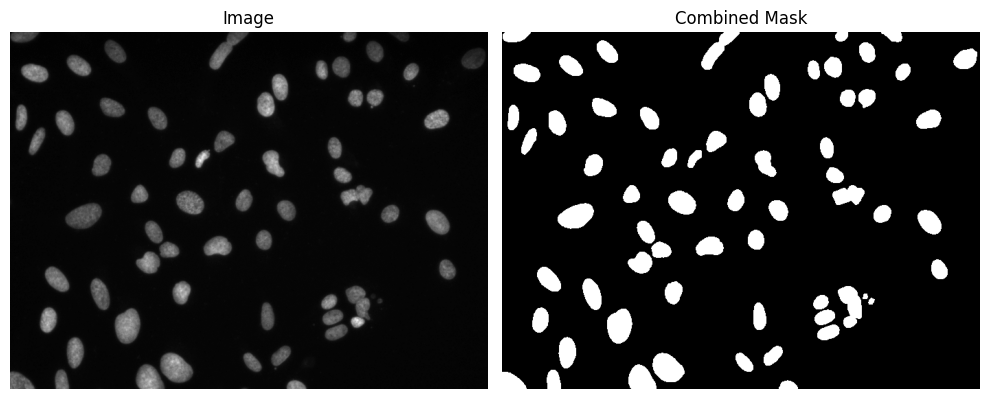

In [15]:
# Visualize sample image and combined mask
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap='gray')
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
if sample_mask is not None:
    plt.imshow(sample_mask, cmap='gray')
    plt.title('Combined Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Watershed (two methods)
def watershed_no_markers(image):
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    markers = measure.label(binary)
    gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, np.ones((3, 3)))
    return watershed(gradient, markers, mask=binary)

def watershed_with_markers(image):
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    markers = measure.label(sure_fg)
    return watershed(-dist, markers, mask=binary)

labels_no_marker = watershed_no_markers(sample_image)
labels_with_marker = watershed_with_markers(sample_image)

print(f'No-marker regions: {labels_no_marker.max()}')
print(f'With-marker regions: {labels_with_marker.max()}')

No-marker regions: 67
With-marker regions: 13


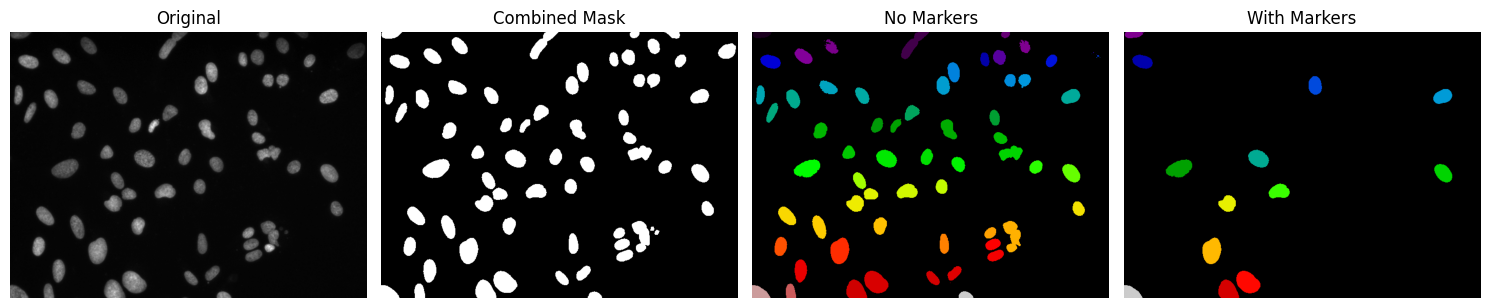

In [17]:
# Visualize segmentation results for the sample image
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(sample_image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
if sample_mask is not None:
    plt.imshow(sample_mask, cmap='gray')
    plt.title('Combined Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(labels_no_marker, cmap='nipy_spectral')
plt.title('No Markers')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(labels_with_marker, cmap='nipy_spectral')
plt.title('With Markers')
plt.axis('off')

plt.tight_layout()
plt.show()